# Healthcare Revenue Cycle Management (RCM) SQL Analysis
This notebook demonstrates advanced SQL techniques for analyzing medical cost and patient data.

In [1]:
import pandas as pd
import sqlite3

# Load the dataset
df = pd.read_csv('/content/medical_cost_personal_datasets.csv')

# Create an in-memory SQLite database to run SQL queries
conn = sqlite3.connect(':memory:')
df.to_sql('insurance', conn, index=False, if_exists='replace')

print('Data loaded into SQL table: insurance')
display(df.head())

Data loaded into SQL table: insurance


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1. Complex SQL Queries for Business Insights
Here are 5 queries designed for RCM analysis, using SQLite syntax.

In [ ]:
def run_query(query):
    return pd.read_sql_query(query, conn)

# Query 1: Average Charges by Region and Smoker Status (Segmented Analysis)
query_1 = """
SELECT
    region,
    smoker,
    COUNT(*) as patient_count,
    ROUND(AVG(charges), 2) as avg_revenue
FROM insurance
GROUP BY region, smoker
ORDER BY avg_revenue DESC;
"""

# Query 2: Identifying High-Cost Outliers (Window Functions)
# Note: SQLite supports window functions in newer versions
query_2 = """
SELECT
    *,
    ROUND(AVG(charges) OVER(PARTITION BY region), 2) as regional_avg,
    ROUND(charges - AVG(charges) OVER(PARTITION BY region), 2) as variance_from_avg
FROM insurance
WHERE charges > 30000
LIMIT 5;
"""

# Query 3: Revenue Distribution by BMI Category (Case Logic)
query_3 = """
SELECT
    CASE
        WHEN bmi < 18.5 THEN 'Underweight'
        WHEN bmi BETWEEN 18.5 AND 24.9 THEN 'Normal'
        WHEN bmi BETWEEN 25 AND 29.9 THEN 'Overweight'
        ELSE 'Obese'
    END AS bmi_category,
    COUNT(*) as patient_count,
    SUM(charges) as total_revenue
FROM insurance
GROUP BY 1
ORDER BY total_revenue DESC;
"""

# Query 4: Percentage Contribution of Smokers to Total Regional Revenue
query_4 = """
WITH RegionalTotal AS (
    SELECT region, SUM(charges) as total_reg_charges
    FROM insurance
    GROUP BY region
)
SELECT
    i.region,
    i.smoker,
    SUM(i.charges) as smoker_revenue,
    ROUND((SUM(i.charges) / rt.total_reg_charges) * 100, 2) as pct_of_region_revenue
FROM insurance i
JOIN RegionalTotal rt ON i.region = rt.region
WHERE i.smoker = 'yes'
GROUP BY i.region;
"""

# Query 5: Age-Based Cohort Revenue Analysis
query_5 = """
SELECT
    (age / 10) * 10 as age_bracket,
    COUNT(*) as volume,
    ROUND(AVG(charges), 2) as avg_ticket_size
FROM insurance
GROUP BY age_bracket
ORDER BY age_bracket ASC;
"""

print("Query 4: Revenue Contribution Example")
display(run_query(query_4))

Query 4: Revenue Contribution Example


,region,smoker,smoker_revenue,pct_of_region_revenue
0,northeast,yes,1.988127e+06,45.77
1,northwest,yes,1.751136e+06,43.39
2,southeast,yes,3.170895e+06,59.12
3,southwest,yes,1.871606e+06,46.64


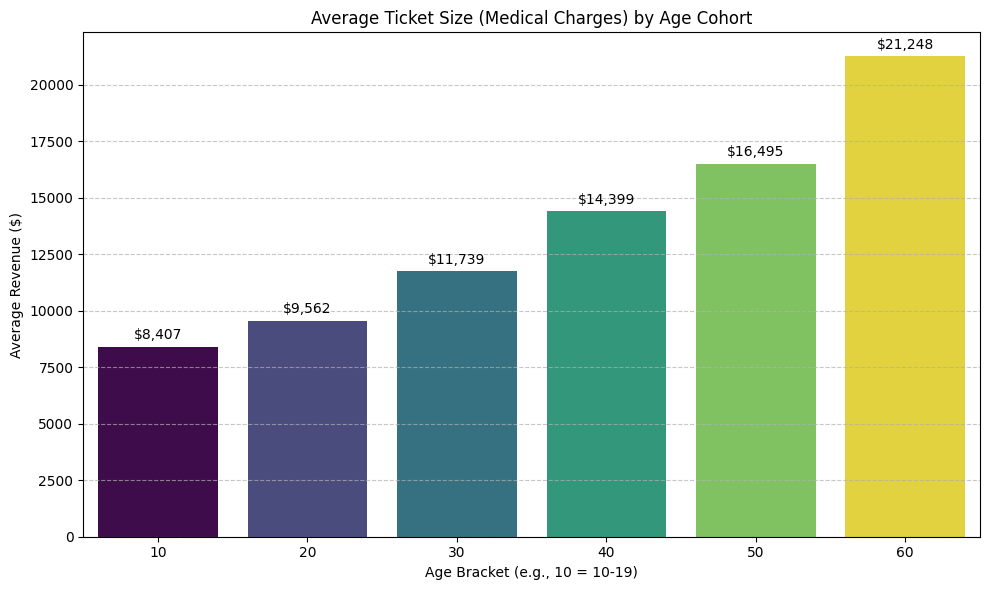

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Run Query 5
age_cohorts = run_query(query_5)

# Create the visualization
plt.figure(figsize=(10, 6))
# Updated hue and legend to satisfy the latest Seaborn API requirements
sns.barplot(x='age_bracket', y='avg_ticket_size', data=age_cohorts, hue='age_bracket', palette='viridis', legend=False)

plt.title('Average Ticket Size (Medical Charges) by Age Cohort')
plt.xlabel('Age Bracket (e.g., 10 = 10-19)')
plt.ylabel('Average Revenue ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of bars
for index, row in age_cohorts.iterrows():
    plt.text(index, row.avg_ticket_size + 200, f'${row.avg_ticket_size:,.0f}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

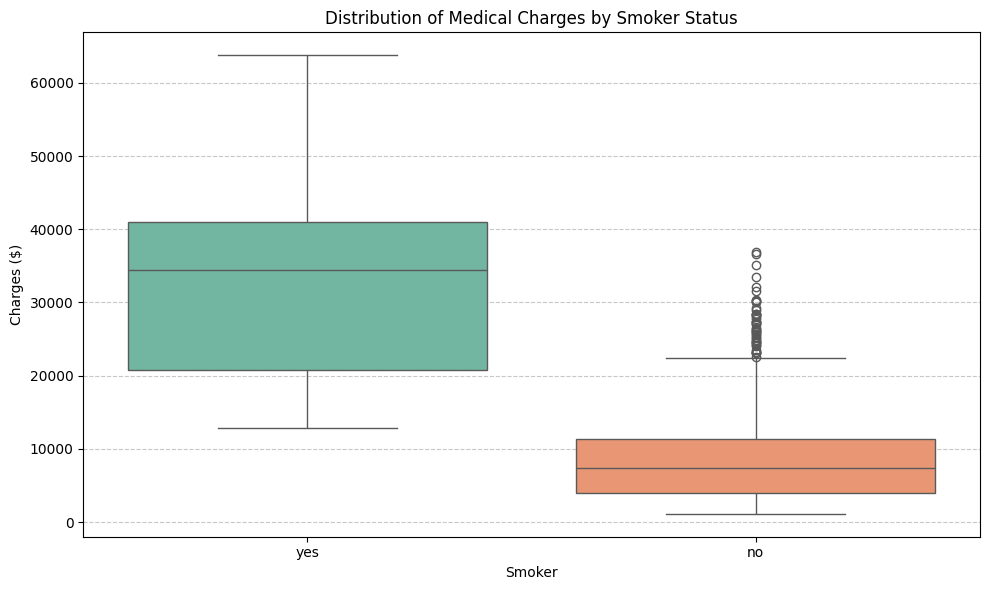

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot to analyze charges by smoker status
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=df, hue='smoker', palette='Set2', legend=False)

plt.title('Distribution of Medical Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

# Separate the charges into two groups
smoker_charges = df[df['smoker'] == 'yes']['charges']
non_smoker_charges = df[df['smoker'] == 'no']['charges']

# Perform independent t-test
t_stat, p_val = stats.ttest_ind(smoker_charges, non_smoker_charges, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("Conclusion: The difference in charges is statistically significant (p < 0.05).")
else:
    print("Conclusion: There is no statistically significant difference in charges (p >= 0.05).")

T-statistic: 32.7519
P-value: 5.8895e-103
Conclusion: The difference in charges is statistically significant (p < 0.05).


In [ ]:
import pandas as pd

# Calculate the Pearson correlation coefficient
correlation = df['bmi'].corr(df['charges'])

print(f"Pearson Correlation Coefficient between BMI and Charges: {correlation:.4f}")

if correlation > 0.5:
    print("There is a strong positive correlation.")
elif correlation > 0.3:
    print("There is a moderate positive correlation.")
elif correlation > 0:
    print("There is a weak positive correlation.")
else:
    print("There is no positive correlation or a negative correlation.")

Pearson Correlation Coefficient between BMI and Charges: 0.1983
There is a weak positive correlation.


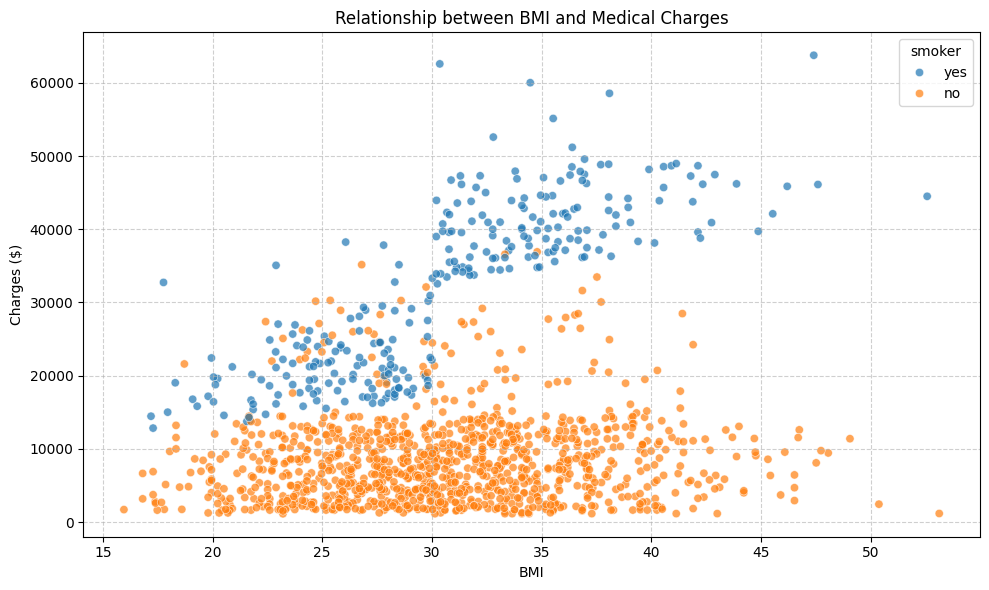

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', data=df, hue='smoker', alpha=0.7)

plt.title('Relationship between BMI and Medical Charges')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

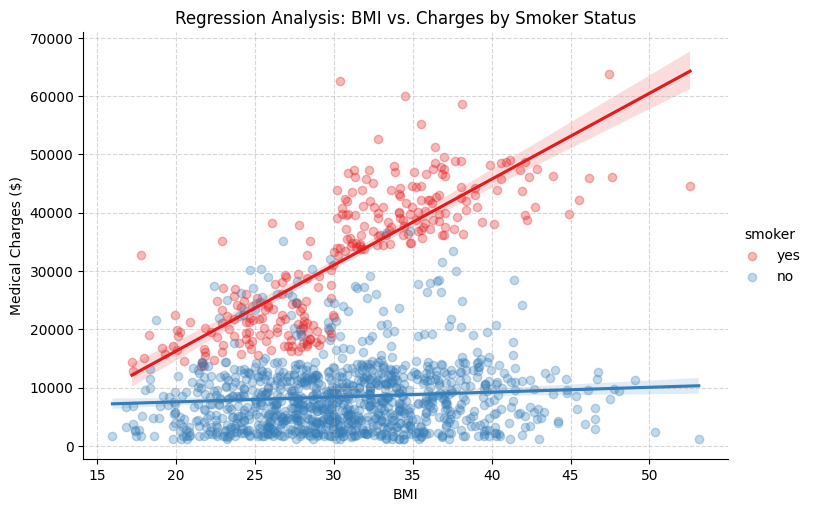

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a regression plot to see the interaction between BMI and Smoker status
plt.figure(figsize=(10, 6))
sns.lmplot(x='bmi', y='charges', hue='smoker', data=df, palette='Set1', aspect=1.5, scatter_kws={'alpha':0.3})

plt.title('Regression Analysis: BMI vs. Charges by Smoker Status')
plt.xlabel('BMI')
plt.ylabel('Medical Charges ($)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## SQL Cheat Sheet for Healthcare RCM

### 1. Common Aggregations
- `SUM(charges)`: Total Gross Revenue.
- `COUNT(claim_id)`: Total Claim Volume.
- `AVG(days_to_pay)`: Speed of Revenue Cycle (Days Sales Outstanding).

### 2. Denials & Adjustments
- `WHERE status = 'Denied'`: Identifying revenue leakage.
- `SUM(adjustment_amount) / SUM(gross_charges)`: Contractual Adjustment Rate.

### 3. Patient Segmentation
- Use `CASE WHEN` for Age brackets (Pediatric, Adult, Geriatric) or BMI categories.

### 4. Payer Performance
- `GROUP BY payer_name` to identify which insurance companies have the highest denial rates or lowest reimbursement averages.

# Final Conclusion & RCM Strategy Recommendations

### Key Insights from Analysis
1. **Primary Cost Driver (Smoking):** Statistical analysis (t-test) and visualizations confirm that smoking status is the single most significant predictor of high medical charges. Smokers contribute a disproportionate percentage of regional revenue (e.g., ~59% in the Southeast).
2. **BMI Interaction:** While BMI has a weak overall correlation with charges (0.1983), our regression analysis revealed a critical 'interaction effect.' For smokers, medical costs escalate sharply as BMI increases, whereas non-smokers see a much flatter cost curve.
3. **Age-Based Revenue Growth:** There is a clear, linear increase in average 'ticket size' as patients age, with the 60+ cohort representing the highest average revenue per patient.
4. **Regional Variance:** The Southeast region shows the highest volume and revenue, largely driven by the high prevalence of smoking and obesity in that segment.

### Strategic Recommendations for RCM
*   **Risk-Adjusted Pricing:** Insurance providers should consider tiered premiums that specifically account for the interaction between smoking and BMI, rather than treating them as independent risks.
*   **Targeted Wellness Programs:** Implementing cessation and weight management programs in high-revenue regions like the Southeast could significantly reduce long-term claim liabilities.
*   **Revenue Forecasting:** RCM teams should use the age-cohort data to predict future revenue streams as the patient population shifts toward older, higher-cost brackets.
*   **Denial Management:** Use the SQL frameworks established here to monitor payer performance and identify if specific categories (like high-BMI claims) are being denied at higher rates.